# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [4]:
import pandas as pd

url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)

#df = pd.read_csv('Exercise2BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [8]:
df.shape

(17379, 17)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [15]:
from sklearn.model_selection import train_test_split
target = 'cnt'

X = df.copy()
y = df[target].astype(float)

X.drop(columns=[target], inplace=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


In [16]:
# Drop unnecessary columns from X_train and X_test
# 'instant' is an index column, 'casual' and 'registered' are components of 'cnt' (target)
# 'dteday' is a date string, its components are already in 'yr', 'mnth', 'hr', 'weekday'
drop_cols = ['instant', 'dteday', 'casual', 'registered']

X_train = X_train.drop(columns=drop_cols, errors='ignore')
X_test = X_test.drop(columns=drop_cols, errors='ignore')

# Identify categorical features for one-hot encoding
categorical_features = [
    'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit'
]

# Convert specified categorical columns to 'category' dtype for easier one-hot encoding
for col in categorical_features:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('category')
    if col in X_test.columns:
        X_test[col] = X_test[col].astype('category')

# Apply one-hot encoding
X_train = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

# Align columns - this is crucial after one-hot encoding, as test set might miss some categories
# or have extra ones compared to the training set. We align based on training columns.
train_cols = X_train.columns
X_test = X_test.reindex(columns=train_cols, fill_value=0)

print("X_train shape after processing:", X_train.shape)
print("X_test shape after processing:", X_test.shape)
display(X_train.head())

X_train shape after processing: (13903, 53)
X_test shape after processing: (3476, 53)


,temp,atemp,hum,windspeed,season_2,season_3,season_4,yr_1,mnth_2,mnth_3,...,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3,weathersit_4
335,0.20,0.1970,0.55,0.2239,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
7035,0.52,0.5000,0.42,0.1045,False,False,True,False,False,False,...,False,True,False,False,False,False,True,False,False,False
8051,0.46,0.4545,1.00,0.2239,False,False,True,False,False,False,...,False,False,True,False,False,False,True,False,True,False
2133,0.46,0.4545,0.31,0.0000,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
8485,0.20,0.2273,0.75,0.1045,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

In [17]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# Initialize an XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Define the parameter grid for GridSearchCV
# These are common hyperparameters to tune for XGBoost
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

# Initialize GridSearchCV
# cv=3 means 3-fold cross-validation
# scoring='neg_mean_squared_error' is used as GridSearchCV maximizes the score, so we use negative MSE
# verbose=1 for progress messages
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1 # Use all available cores
)

# Fit GridSearchCV to the training data
print("Starting Grid Search for XGBoost...")
grid_search.fit(X_train, y_train)
print("Grid Search complete.")

# Get the best parameters and best score
best_xgb_params = grid_search.best_params_
best_xgb_score = -grid_search.best_score_ # Convert back to positive MSE

print("\nBest XGBoost Parameters:", best_xgb_params)
print("Best XGBoost Negative Mean Squared Error (Cross-Validation):", best_xgb_score)

Starting Grid Search for XGBoost...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Grid Search complete.

Best XGBoost Parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}
Best XGBoost Negative Mean Squared Error (Cross-Validation): 2849.280616337533


## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [19]:
# Your code here
from sklearn.linear_model import LinearRegression

# Create a Linear Regression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Predict the test data with the fitted model
y_pred = model.predict(X_test)


In [23]:
import xgboost as xgb

# Create an XGBoost Regressor model using the best parameters
xgb_best_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, **best_xgb_params)

# Fit the XGBoost model to the training data
print("Training XGBoost model with best parameters...")
xgb_best_model.fit(X_train, y_train)
print("XGBoost model training complete.")

# Predict the test data with the fitted XGBoost model
y_pred_xgb = xgb_best_model.predict(X_test)

Training XGBoost model with best parameters...
XGBoost model training complete.


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Mean Absolute Error: {mae_xgb}")
print(f"XGBoost Mean Squared Error: {mse_xgb}")
print(f"XGBoost R-squared: {r2_xgb}")

XGBoost Mean Absolute Error: 33.80354981776648
XGBoost Mean Squared Error: 2480.8185980066905
XGBoost R-squared: 0.9216552543200189


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Absolute Error: 74.10515899029579
Mean Squared Error: 10089.38811515939
R-squared: 0.681375112801918


### Model Performance Comparison

Based on the comparison:

*   **Mean Absolute Error (MAE):** XGBoost has a significantly lower MAE (33.80) compared to Linear Regression (74.11). This means, on average, the XGBoost model's predictions are closer to the actual values.
*   **Mean Squared Error (MSE):** XGBoost also shows a much lower MSE (2480.82) than Linear Regression (10089.39). The lower MSE indicates that XGBoost has smaller prediction errors, especially penalizing larger errors more.
*   **R-squared:** XGBoost has a higher R-squared value (0.92) compared to Linear Regression (0.68). This suggests that XGBoost explains a much larger proportion of the variance in the target variable (`cnt`) than the Linear Regression model.

In conclusion, the **XGBoost model demonstrates superior performance** over the Linear Regression model for this bike sharing demand prediction task, achieving better accuracy and explaining more of the data's variability.

## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [ ]:
# Your code here

In [31]:
print('--- Linear Regression Model Performance ---')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')
print('\n--- XGBoost Model Performance ---')
print(f'Mean Absolute Error: {mae_xgb:.2f}')
print(f'Mean Squared Error: {mse_xgb:.2f}')
print(f'R-squared: {r2_xgb:.2f}')

# You can also create a DataFrame for a more structured comparison
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'R-squared'],
    'Linear Regression': [mae, mse, r2],
    'XGBoost': [mae_xgb, mse_xgb, r2_xgb]
})

display(comparison_df.round(2))

--- Linear Regression Model Performance ---
Mean Absolute Error: 74.11
Mean Squared Error: 10089.39
R-squared: 0.68

--- XGBoost Model Performance ---
Mean Absolute Error: 33.80
Mean Squared Error: 2480.82
R-squared: 0.92


,Metric,Linear Regression,XGBoost
0,MAE,74.11,33.80
1,MSE,10089.39,2480.82
2,R-squared,0.68,0.92


## Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

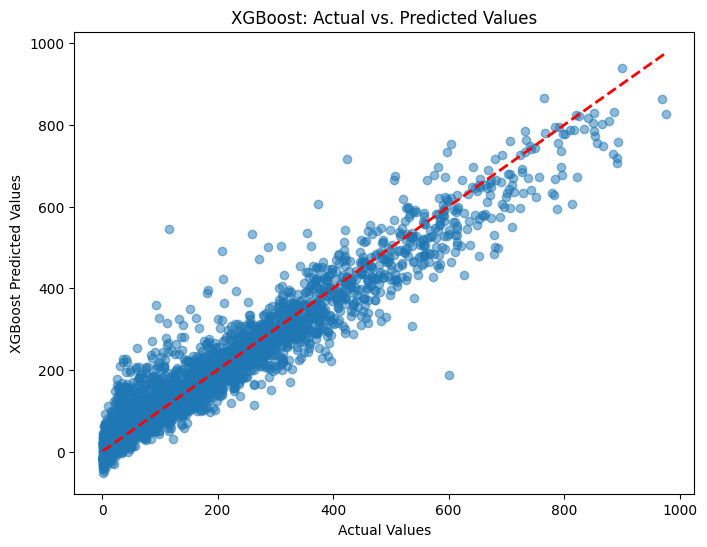

In [ ]:
import matplotlib.pyplot as plt

# Create a scatter plot to visualize the relationship for XGBoost predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5)  # Plot actual vs. XGBoost predicted values

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("XGBoost Predicted Values")
plt.title("XGBoost: Actual vs. Predicted Values")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()

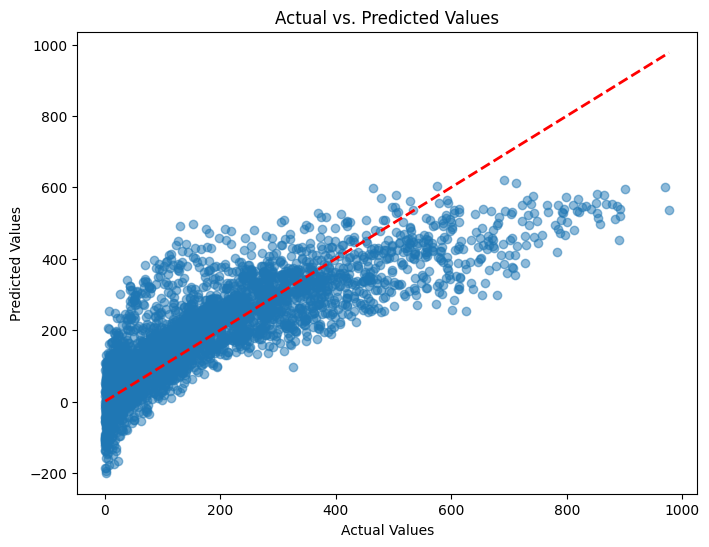

In [30]:
import matplotlib.pyplot as plt

# y_test contains the actual target values for the test dataset
# y_pred contains the predicted values for the test dataset

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)  # Plot actual vs. predicted values

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()